In [1]:
from fastai.vision.all import *

In [2]:
torch.cuda.is_available()

True

In [3]:
torch.cuda.get_device_name(0)

'NVIDIA GeForce RTX 3080 Ti'

In [216]:
sampling_frequency = 200 # Hz

In [217]:
import pandas as pd
import numpy as np

from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hamming

def create_spectrograms(df : pd.DataFrame, fault_category : str, SECONDS : int=2, nperseg=None, train_seconds=None, val_seconds=None, test_seconds=None, mode='train'):
    """
    Generates and returns spectrograms for specified time segments.

    Parameters:
    dataDict (dict): Dict containing fault category data.
    fault_category (str): Category to process.
    SECONDS (int): Length of each spectrogram segment in seconds.
    nperseg (int): FFT window size.
    train_seconds (list of tuples): List of (start, end) in seconds for training.            all_labels.append(fault_category)
    val_seconds (list of tuples): List of (start, end) in seconds for validation.
    mode (str): 'train' or 'val' - determines which segments to use.

    Returns:
    spectrograms, labels
    """
    all_spectrograms = []
    all_labels = []
    segments = []

    treshold = 5

    peak_time = df[df["sensor_1"] == df["sensor_1"].max()]["time_sec"].max()

    start_time = peak_time - treshold
    end_time = peak_time + treshold
    
    segments.append((start_time, end_time))

    for start_sec, end_sec in segments:

        spec_8ch = get_8_channel_spectrogram(
            df[(df["time_sec"] >= start_time) & (df["time_sec"] <= end_time)], nperseg)

        all_spectrograms += spec_8ch

        # One fault category for each sensor (the fault is the same)
        all_labels.append(fault_category)
        all_labels.append(fault_category)
        all_labels.append(fault_category)
        all_labels.append(fault_category)


        print(f"Generated {1} spectrograms - label: {fault_category}")

    return all_spectrograms, all_labels

def get_8_channel_spectrogram(data, sampling_frequency = 200, nperseg = 256):

    all_spectrograms = []

    # Slice to first 5 seconds if desired
    
    for column in data:
        if column.startswith("sensor_1") or column.startswith("sensor_2") or column.startswith("sensor_3") or column.startswith("sensor_4"): # This can be used to filter out specific columns
            
            col = data[column]
            w = hamming(nperseg) # Hamming window
            Sft = ShortTimeFFT(w, hop=int(nperseg*0.25), fs=sampling_frequency, scale_to='psd')
            Sxx = Sft.spectrogram(col.values)  # calculate absolute square of STFT
            all_spectrograms.append(Sxx)

    return all_spectrograms

In [218]:
from pathlib import Path

import pandas as pd
import os

def get_data(dir: Path, fault_category: str):
    directory = os.listdir(str(dir))
    
    data = []
    fault_labels = []

    for file in directory:
        if (("Session" in file and "_rel_time" in file)):
            df = pd.DataFrame(pd.read_csv(str(dir/file)))
            spec, labels = create_spectrograms(df, fault_category, SECONDS=4, nperseg=256, train_seconds=[(df["time_sec"].min(), df["time_sec"].max())])
            data += spec
            fault_labels += labels
    
    return data, fault_labels

In [219]:
all_spectograms = []
all_labels = []

In [220]:
hard_falls, hard = get_data(Path('.data/train/hardFall'), "Hard Fall")
all_spectograms += hard_falls
all_labels += hard

Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label: Hard Fall
Generated 1 spectrograms - label

In [221]:
controlled_falls, controlled = get_data(Path('.data/train/controlledFall'), 'Controlled Fall')
slip_trip_falls, slip_trip = get_data(Path('.data/train/Slip/Trip'), 'SlipTrip')

all_spectograms += controlled_falls
all_labels += controlled

all_spectograms += slip_trip_falls
all_labels += slip_trip

Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall
Generated 1 spectrograms - label: Controlled Fall


In [235]:
def pick_2d(spec_like):
    """Accept [array], array, (1,F,T), (F,T,1), (C,F,T), etc. → return 2D (F, T)."""
    arr = spec_like[0] if isinstance(spec_like, (list, tuple)) else np.asarray(spec_like)
    # Squeeze singleton dims
    if arr.ndim >= 3 and 1 in arr.shape:
        arr = np.squeeze(arr)
    if arr.ndim == 3:         # pick first channel if still 3D
        arr = arr[0]
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D spectrogram after squeezing, got {arr.shape}")
    # Heuristic: freq bins are usually fewer than time frames
    F, T = arr.shape
    if F > T:
        arr = arr.T  # ensure (F, T)
    return arr  # (F, T), linear PSD

def power_to_db(power, ref=1.0, floor_db=-100.0, eps=1e-18):
    """Linear PSD → dB re `ref` (default 1 unit²/Hz)."""
    db = 10.0 * np.log10(np.maximum(power, eps) / ref)
    return np.maximum(db, floor_db)

def _unit_label(unit: str, scale: str):
    # For colorbar label
    if scale == "linear":
        return f"{unit}^2/Hz"
    # dB
    return f"dB re 1 {unit}^2/Hz"

def plot_vibration_spectrogram(
    spec_like,
    *,
    fs=200,           # sampling rate [Hz] → for axis in seconds/Hz (optional)
    hop=64,          # hop size [samples] (optional)
    nperseg=256,      # window length → for freq bins (optional; improves extent)
    unit="g",          # "g" or "m/s^2" (use whatever your PSD unit is)
    scale="dB",        # "dB" or "linear"
    db_floor=-5.0,
    title=None,
    fmax=None          # optionally cap visible frequency (Hz)
):
    S = pick_2d(spec_like)  # (F, T), linear PSD in unit^2/Hz
    F, T = S.shape

    # Convert to dB if requested
    if scale.lower() == "db":
        S_plot = power_to_db(S, ref=1.0, floor_db=db_floor)
    else:
        S_plot = S

    # Build axes if fs/hop provided; else fall back to frames/bins
    extent = None
    if fs is not None and hop is not None:
        # Frequency vector (best with nperseg; else infer from F)
        if nperseg is None:
            # F should equal nfft//2 + 1 → infer nperseg roughly
            nperseg = (F - 1) * 2
        freqs = np.fft.rfftfreq(nperseg, d=1.0/fs)
        # Map vertical bins to these centers
        # If freqs length mismatches slightly, just limit to min length
        m = min(len(freqs), F)
        freqs = freqs[:m]
        S_plot = S_plot[:m, :]
        # Time axis from hop
        times = np.arange(T) * (hop / fs)
        extent = [times[0], times[-1] + hop / fs, freqs[0], freqs[-1]]

    # Apply frequency cap for visualization if requested
    if fmax is not None and extent is not None:
        # Compute row index for fmax
        f0, f1 = extent[2], extent[3]
        if fmax < f1:
            frac = (fmax - f0) / (f1 - f0)
            rows = int(max(1, np.floor(frac * S_plot.shape[0])))
            S_plot = S_plot[:rows, :]
            extent[3] = fmax

    # Titles and labels
    if title is None:
        base = "Acceleration PSD Spectrogram"
        title = base + (" (dB)" if scale.lower() == "db" else " (linear)")

    plt.figure(figsize=(8, 4))
    im = plt.imshow(
        S_plot,
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=extent  # None → frames/bins; else seconds/Hz
    )
    cbar = plt.colorbar(im)
    cbar.set_label(_unit_label(unit, scale=scale.lower()))
    plt.xlabel("Time (s)" if extent is not None else "Time (frames)")
    plt.ylabel("Frequency (Hz)" if extent is not None else "Frequency (bins)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [236]:
len(all_labels)

540

In [237]:
len(all_spectograms)

540

In [225]:
def split():
    valid_spec = []
    valid_labels = []

    size : int = 60
    
    for i in range(0, size):
        ran_num = random.randint(0, len(all_labels))

        del all_spectograms [ran_num]
        del all_labels [ran_num]

        valid_spec.append(all_spectograms[ran_num])
        valid_labels.append(all_labels[ran_num])
    
    return valid_spec, valid_labels

In [226]:
valid_spec, valid_labels = split()

In [238]:
def get_label_index(label : str):

    for i in range(len(all_labels)):
        if all_labels[i] == label:
            print(i)
            break

In [239]:
hard_falls[0].shape

(129, 35)

In [240]:
len(all_spectograms)

540

In [241]:
print(f'Initial shape of a spectrogram: ', all_spectograms[0].shape)

ch, freq_bins = all_spectograms[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx)
print(f'Final shape: {final_shape}')
print(f'Input Type: {type(all_spectograms[0])}')


Initial shape of a spectrogram:  (129, 35)
Final shape: (129, 9)
Input Type: <class 'numpy.ndarray'>


In [242]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [243]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

def create_tensor_image(i : int):
        """
        Convert spectrogram to TensorImage format
        """
        # Normalization - turn spectrogram into dB scale
        arr_db = 10 * np.log10(all_spectograms[i])
        arr_db = np.clip(arr_db, FLOOR_DB, 0)

        # Scale to [0, 1]
        arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr_db.shape) == 3:
                arr_db = np.mean(arr_db, axis=-1)  # average across channels
        
        arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = plt.get_cmap('magma')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr_01)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return all_labels[i]

In [244]:
get_label_index("Controlled Fall")

175


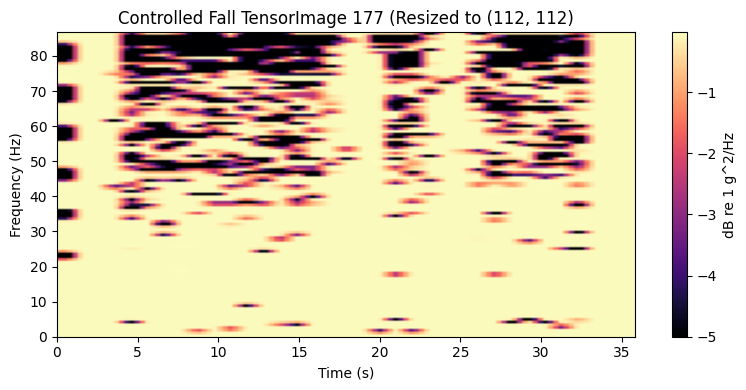

In [245]:
plot_vibration_spectrogram(create_tensor_image(175), title=f'Controlled Fall TensorImage {177} (Resized to {TARGET_HW}')

In [246]:
get_label_index("Hard Fall")

0


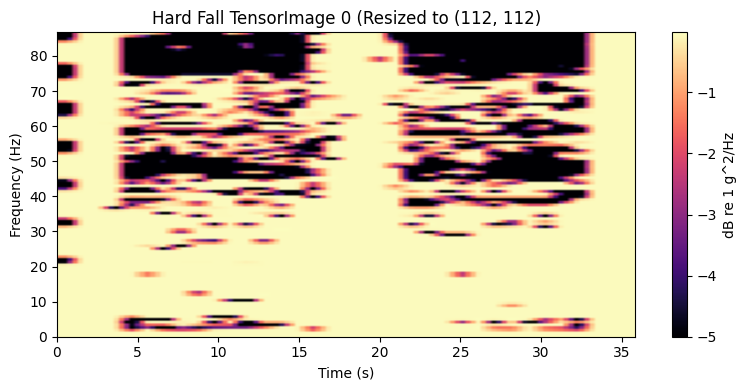

In [247]:
plot_vibration_spectrogram(create_tensor_image(0), title=f'Hard Fall TensorImage {0} (Resized to {TARGET_HW}')

In [248]:
get_label_index("SlipTrip")

352


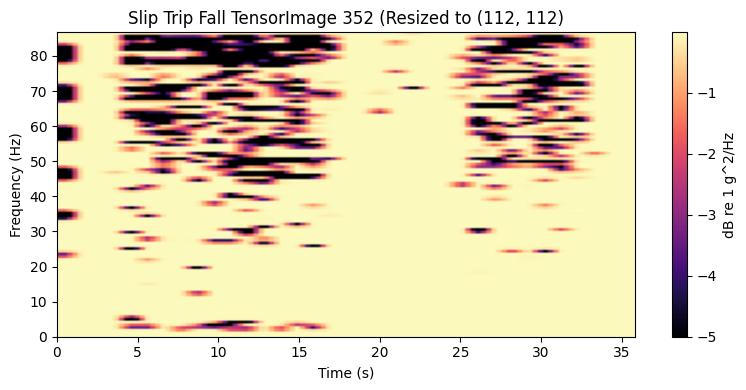

In [251]:
plot_vibration_spectrogram(create_tensor_image(352), title=f'Slip Trip Fall TensorImage {352} (Resized to {TARGET_HW}')


In [73]:
def time_series_splitter(items):
    n_train = len(all_spectograms)
    return list(range(n_train)), list(range(n_train, len(items)))

In [252]:
block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=create_tensor_image,
    get_y=get_y,
)

In [253]:
len(all_spectograms)

540

In [254]:
len(all_labels)

540

In [255]:
items = list(range(len(all_spectograms)))   # or `range(N)`
dls = block.dataloaders(items, bs=16)

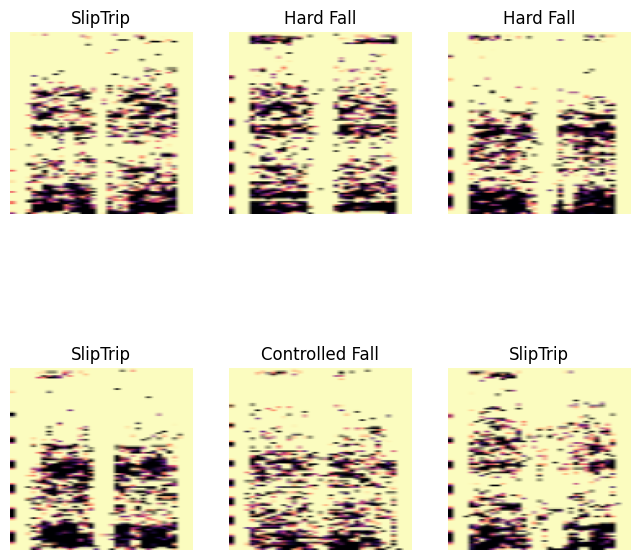

In [256]:
dls.show_batch(max_n=6, figsize=(8,8))

In [257]:
model = nn.Sequential(
    
    nn.Conv2d(3, 8, kernel_size=4, stride=2),     # (8, 55, 55)
    nn.BatchNorm2d(8),
    nn.ReLU(),
            
    nn.Conv2d(8, 16, kernel_size=3, stride=2),     # (16, 27, 27)
    nn.BatchNorm2d(16),
    nn.ReLU(),
        
    nn.Conv2d(16, 32, kernel_size=3, stride=2),    # (32, 13, 13)
    nn.BatchNorm2d(32),
    nn.ReLU(),

    nn.Conv2d(32, 64, kernel_size=3, stride=2),    # (64, 6, 6)
    nn.BatchNorm2d(64),
    nn.ReLU(),

    nn.Flatten(),
    nn.Linear(64*6*6, 14)
)

In [258]:
learner = Learner(dls, model=model, loss_func=CrossEntropyLossFlat(), metrics=error_rate)

In [259]:
learner.summary()

Sequential (Input shape: 16 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     16 x 8 x 55 x 55    
Conv2d                                    392        True      
BatchNorm2d                               16         True      
ReLU                                                           
____________________________________________________________________________
                     16 x 16 x 27 x 27   
Conv2d                                    1168       True      
BatchNorm2d                               32         True      
ReLU                                                           
____________________________________________________________________________
                     16 x 32 x 13 x 13   
Conv2d                                    4640       True      
BatchNorm2d                               64         True      
ReLU                                                           
___________________________________

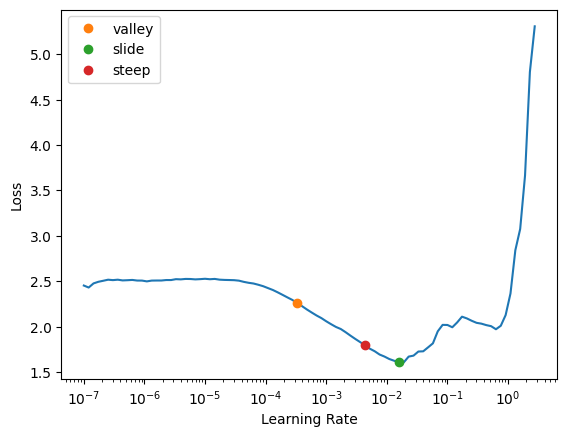

In [260]:
lr = learner.lr_find(suggest_funcs=(valley,slide,steep))

In [261]:
learner.fit_one_cycle(20, lr.valley)

epoch,train_loss,valid_loss,error_rate,time
0,2.229304,2.229367,0.629630,00:00
1,1.711991,1.190178,0.518519,00:00
2,1.333368,0.955083,0.351852,00:00
3,1.065115,0.838267,0.370370,00:00
4,0.843987,0.744670,0.240741,00:00
5,0.651895,0.677297,0.287037,00:00
6,0.496534,0.632840,0.250000,00:00
7,0.373055,0.589033,0.212963,00:00
8,0.280564,0.558741,0.212963,00:00
9,0.209285,0.536832,0.175926,00:00


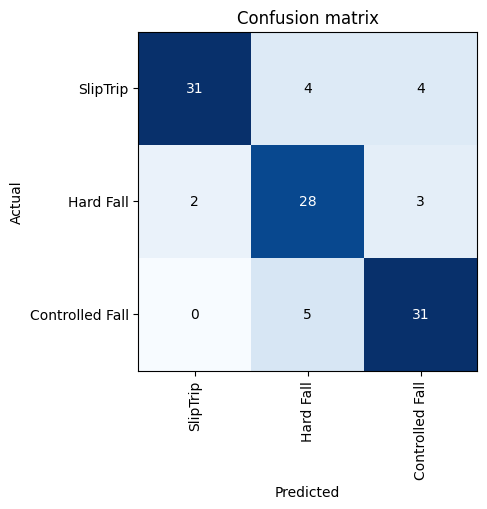

In [262]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [263]:
inter_plot.most_confused()

[('Controlled Fall', 'Hard Fall', np.int64(5)),
 ('SlipTrip', 'Hard Fall', np.int64(4)),
 ('SlipTrip', 'Controlled Fall', np.int64(4)),
 ('Hard Fall', 'Controlled Fall', np.int64(3)),
 ('Hard Fall', 'SlipTrip', np.int64(2))]

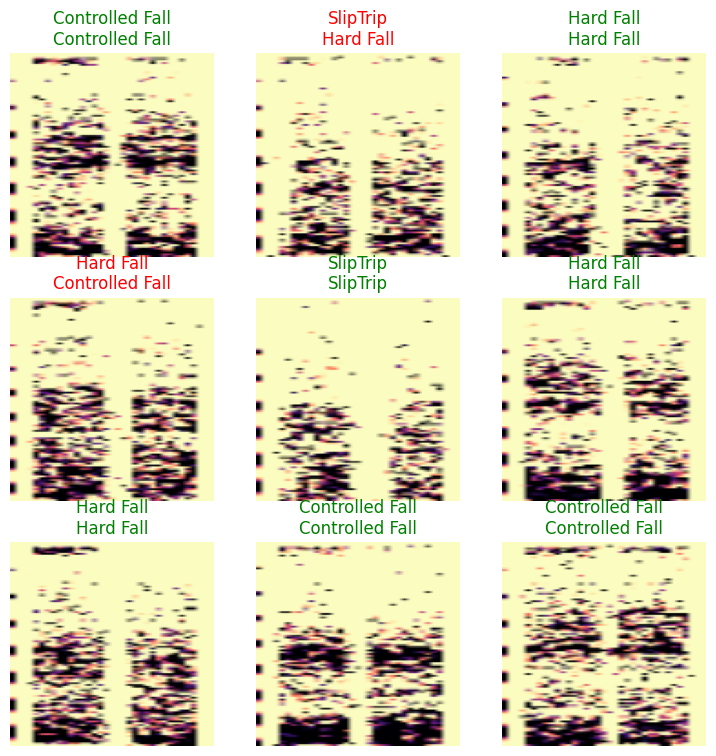

In [264]:
learner.show_results()

In [265]:
def get_x_test(i):
    arr_db = 10 * np.log10(valid_spec[i])

    arr_db = np.clip(arr_db, FLOOR_DB, 0)

    # Scale to [0, 1]
    arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr_db.shape) == 3:
            arr_db = np.mean(arr_db, axis=-1)  # average across channels
    
    arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('magma')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr_01)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [266]:
learner.validate()

(#2) [0.4738907516002655,0.1666666716337204]

## Accuracy

This is the relationship between True labes, and all predicted labels. This determens how accurate the model is to predict the true lables. 

$$Accuracy = \frac{TP + TN}{TP + TN + FN + FP} $$

## Precision

The amount of True (or False) labels the model did find belonging to the positive class. The number of True Positives divided by True Positives plus False Positives.  

$$ Precision = \frac{TP}{TP + FP} $$

In [267]:
def get_y_pred(learner: Learner, val_set : list):
    y_pred = []
    y_test = []
    
    for i in range(len(val_set)):
        y_pred.append(learner.predict(get_x_test(i))[0])
        y_test.append(get_y_test(i))
    return y_pred, y_test 
    


In [268]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [269]:
y_pred, y_test = get_y_pred(learner, valid_spec)

In [270]:
accuracy_score(y_test, y_pred)

0.95

In [271]:
precision_score(y_test, y_pred, average='weighted')

0.9524725274725275

In [272]:
recall_score(y_test, y_pred, average="weighted")

0.95

In [273]:
f1_score(y_test, y_pred, average="weighted")

0.9500051872600892

In [274]:
dir = Path('./models')

learner.path = dir

learner.export('classifier.pkl')